# Where Uganda needs irrigation, and where it could work
**Rainfall:** CHIRPS daily, averaged over each of Uganda's 135 districts (2020 boundaries), January 1991 – August 2026
**Water balance and crops:** TerraClimate monthly water deficit, and MODIS NDVI (Terra and Aqua) over cropland, 2000–2024
**Water and land:** permanent surface water (JRC), rivers with at least 1 m³/s mean flow (HydroSHEDS), slope (SRTM), cropland (ESA WorldCover 2021), population (WorldPop 2020), groundwater (British Geological Survey), existing irrigation (FAO, about 2005)

**Questions**
1. How often do dry spells and failed seasons hit each district's growing season?
2. Do dry spells actually show up in crop condition?
3. Where is water within reach of cropland, from rivers, lakes or groundwater?
4. Which districts combine high need with water within reach?
5. How sensitive is that answer to the choices behind it?

In [1]:
import sys, warnings
sys.path.insert(0, '../scripts')
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from irrigation import (PROC, LONG_DRY_SPELL, load_districts, load_rain_daily, load_monthly, load_static,
                        load_groundwater, load_gmia, rainfall_regime, season_rain, season_monthly,
                        need_metrics, need_feasibility, pct_rank, district_map)

INK, GREY, LIGHT, GRID = '#1a1a1a', '#6b6b6b', '#b5b3ad', '#e6e4df'
WET, DRY = '#2b6c9e', '#c4572e'
GROUPS = {'high need, water within reach': '#c4572e', 'high need, water hard to reach': '#e8b49e',
          'lower need, water within reach': '#2b6c9e', 'lower need, harder access': '#cfc8b8',
          'too little cropland mapped': '#e6e4df'}
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'medium',
    'axes.titlelocation': 'left', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c4', 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'xtick.color': GREY, 'ytick.color': GREY, 'axes.labelcolor': GREY,
    'legend.frameon': False,
})
pd.set_option('display.width', 200)
MON = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

## 1. Rainfall seasons
Each district is classed from its 1991–2020 monthly rainfall: **two seasons** when the June–August dip falls below 60% of the smaller of the two peaks (March–May and September–November), otherwise **one long season**. To compare districts fairly, every district is measured over two three-month growing windows: March–May and September–November where there are two seasons, April–June and July–September where there is one.

regime    bimodal  unimodal
region                     
Central        26         0
Eastern        15        22
Northern        1        36
Western        34         1

Districts within 0.1 of the cut-off (classification could go either way): Bugweri, Kamuli, Iganga, Luuka, Buyende, Masindi, Kaberamaido, Buliisa, Tororo, Amolatar, Namutumba, Serere, Kaliro, Pakwach, Manafwa, Apac, Kwania, Kibuku, Butaleja, Dokolo, Namisindwa, Nebbi, Kiryandongo, Kalaki, Mbale


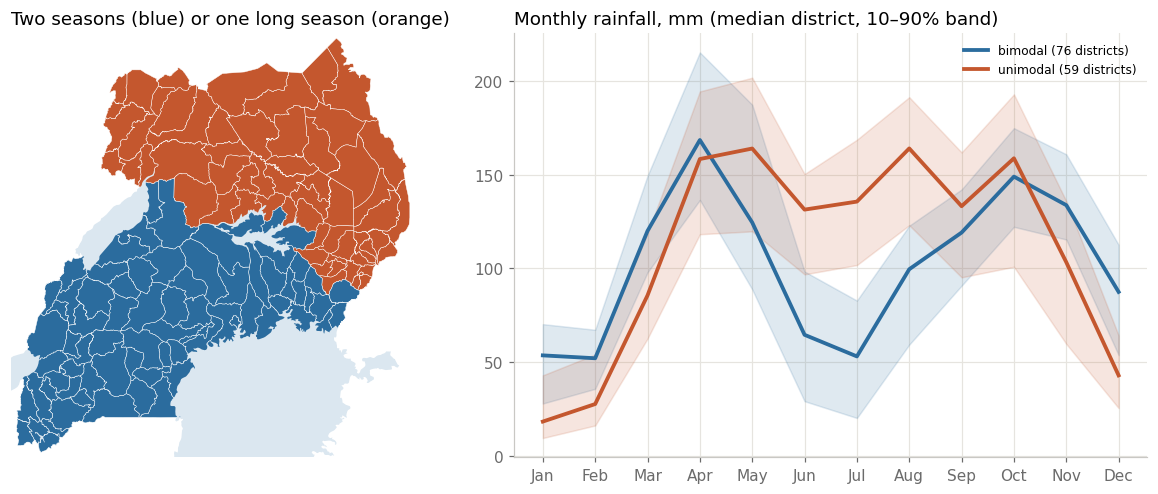

In [2]:
rain = load_rain_daily()
names = pd.DataFrame([{k: d[k] for k in ('pcode', 'district', 'region')} for d in load_districts()]).set_index('pcode')
regime, clim = rainfall_regime(rain)
regime = regime.join(names)
print(pd.crosstab(regime['region'], regime['regime']))
print('\nDistricts within 0.1 of the cut-off (classification could go either way):',
      ', '.join(regime[(regime['trough_to_peak'] - 0.6).abs() < 0.1].sort_values('trough_to_peak')['district']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={'width_ratios': [1, 1.3]})
district_map(axes[0], regime['regime'], colors={'bimodal': WET, 'unimodal': DRY})
axes[0].set_title('Two seasons (blue) or one long season (orange)')
ann = rain.loc['1991':'2020']
mclim = (ann.groupby([ann.index.year, ann.index.month]).sum().groupby(level=1).mean())
for reg, col in [('bimodal', WET), ('unimodal', DRY)]:
    ids = regime.index[regime['regime'] == reg]
    axes[1].plot(MON, mclim[ids].median(axis=1), color=col, lw=2.5, label=f"{reg} ({len(ids)} districts)")
    axes[1].fill_between(MON, mclim[ids].quantile(.1, axis=1), mclim[ids].quantile(.9, axis=1), color=col, alpha=.15)
axes[1].set_title('Monthly rainfall, mm (median district, 10–90% band)'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Dry spells and failed seasons, 1991–2025
A **dry day** has under 2 mm of rain (district averages smear light showers, so 1 mm would undercount dry days; tested in section 7). A **long dry spell** is 14 or more dry days in a row within a growing window: two weeks without rain during growth cuts maize and bean yields sharply. A **failed window** has under 75% of its 1991–2020 median rain.

9,450 district growing windows, 1991–2025

By region (median district):
          p_long_dry  p_failed  mean_spell  window_rain
region                                                 
Central         0.05      0.03        7.06       415.75
Eastern         0.11      0.04        8.59       458.39
Northern        0.09      0.10        8.04       420.28
Western         0.07      0.01        7.30       382.93

Highest odds of a long dry spell:
     district   region  p_long_dry  p_failed  mean_spell
       Moroto Northern        0.73      0.17       18.04
      Kaabong Northern        0.66      0.16       17.36
      Karenga Northern        0.57      0.14       15.03
       Amudat Northern        0.49      0.09       13.77
       Kotido Northern        0.40      0.16       13.59
        Napak Northern        0.37      0.13       12.66
    Nabilatuk Northern        0.26      0.10       11.61
     Rwampara  Western        0.23      0.01       10.27
        Bukwo  Eastern        0.23      0.03

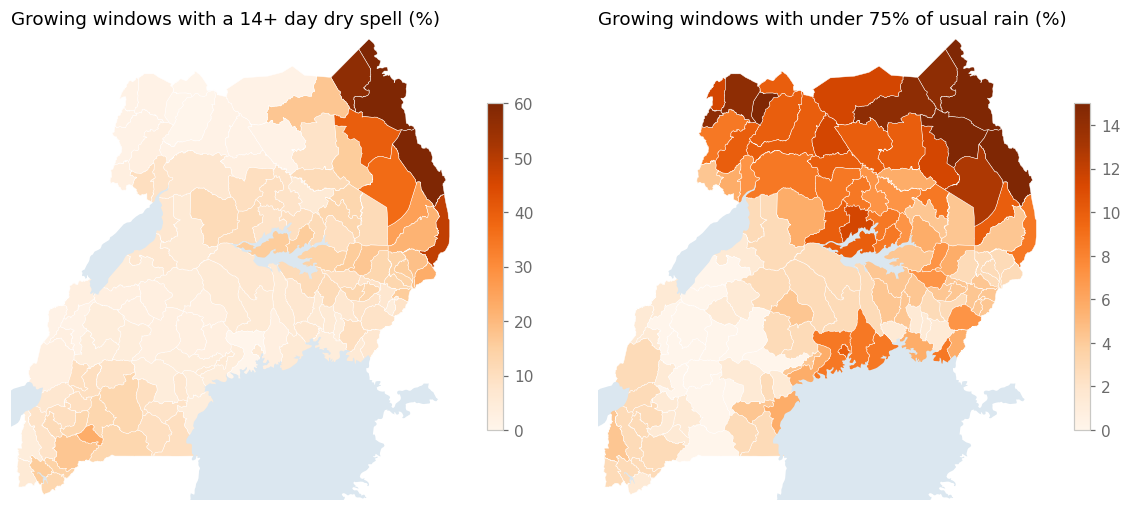

In [3]:
seasons = season_rain(rain.loc[:'2025'], regime)
need = need_metrics(seasons).join(names)
print(f"{len(seasons):,} district growing windows, {seasons['year'].min()}–{seasons['year'].max()}")
print('\nBy region (median district):')
print(need.groupby('region')[['p_long_dry', 'p_failed', 'mean_spell', 'window_rain']].median().round(2))
print('\nHighest odds of a long dry spell:')
print(need.sort_values('p_long_dry', ascending=False).head(12)[['district', 'region', 'p_long_dry', 'p_failed', 'mean_spell']].round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
sm = district_map(axes[0], need['p_long_dry'] * 100, cmap='Oranges', vmin=0, vmax=60)
axes[0].set_title('Growing windows with a 14+ day dry spell (%)'); fig.colorbar(sm, ax=axes[0], shrink=.7)
sm = district_map(axes[1], need['p_failed'] * 100, cmap='Oranges', vmin=0, vmax=15)
axes[1].set_title('Growing windows with under 75% of usual rain (%)'); fig.colorbar(sm, ax=axes[1], shrink=.7)
plt.tight_layout(); plt.show()

In [4]:
# Has the risk changed? Share of windows with a long dry spell, first half against second half of the record
s = seasons.join(names, on='pcode').assign(long_dry=lambda x: x['dry_spell'] >= LONG_DRY_SPELL)
s['period'] = np.where(s['year'] <= 2008, '1991–2008', '2009–2025')
print((s.pivot_table(index='region', columns='period', values='long_dry', aggfunc='mean') * 100).round(1))
res = smf.ols('long_dry ~ year + C(pcode) + C(season)', s.assign(long_dry=s['long_dry'].astype(float))).fit(
    cov_type='cluster', cov_kwds={'groups': s['year']})
print(f"\nNational trend: {res.params['year'] * 1000:+.1f} percentage points per decade (t = {res.tvalues['year']:.1f}, errors clustered by year)")

period    1991–2008  2009–2025
region                        
Central         6.7        3.7
Eastern        10.2       11.6
Northern       14.9       14.7
Western         7.9        8.7

National trend: +0.4 percentage points per decade (t = 0.3, errors clustered by year)


## 3. Do dry spells show up in crops?
Peak crop greenness (NDVI over cropland) in each growing window, compared with that window's rain. Greenness is expressed as an anomaly from each district's own trend, so slow changes (sensor drift, the fixed 2021 cropland map) drop out. Windows where under half the cropland was seen cloud-free are left out.

In [5]:
monthly = load_monthly()
sm_ = season_monthly(monthly, regime)
d = seasons.merge(sm_, on=['pcode', 'year', 'season']).join(names, on='pcode')
d = d.dropna(subset=['ndvi_peak'])
d = d[(d['ndvi_good'] >= 0.5) & (d['year'] >= 2001)]
def detrend(g):
    b = np.polyfit(g['year'], g['ndvi_peak'], 1)
    return g['ndvi_peak'] - np.polyval(b, g['year'])
d['ndvi_anom'] = d.groupby(['pcode', 'season'], group_keys=False)[['year', 'ndvi_peak']].apply(detrend)
for c in ['rain', 'dry_spell']:
    d[c + '_z'] = d.groupby(['pcode', 'season'])[c].transform(lambda x: (x - x.mean()) / x.std())
d['long_dry'] = (d['dry_spell'] >= LONG_DRY_SPELL).astype(float)
print(f"{len(d):,} district windows with good satellite coverage, {d['year'].min()}–{d['year'].max()}")

rows = []
for reg_name, x in [('All districts', d)] + list(d.groupby('region')):
    for term in ['rain_z', 'long_dry']:
        r = smf.ols(f'ndvi_anom ~ {term} + C(season)', x).fit(cov_type='cluster', cov_kwds={'groups': x['year']})
        rows.append({'districts': reg_name, 'measure': {'rain_z': 'rain +1 SD', 'long_dry': '14+ day dry spell'}[term],
                     'NDVI change (x1000)': r.params[term] * 1000, 't': r.tvalues[term], 'windows': int(r.nobs),
                     'typical NDVI swing (x1000)': x['ndvi_anom'].std() * 1000})
crop = pd.DataFrame(rows)
print(crop.round(1).to_string(index=False))

6,288 district windows with good satellite coverage, 2001–2024
    districts           measure  NDVI change (x1000)    t  windows  typical NDVI swing (x1000)
All districts        rain +1 SD                 10.8  9.1     6288                        26.5
All districts 14+ day dry spell                -10.4 -4.7     6288                        26.5
      Central        rain +1 SD                  7.4  4.8     1200                        22.7
      Central 14+ day dry spell                 10.9  2.3     1200                        22.7
      Eastern        rain +1 SD                 13.5  7.9     1728                        25.7
      Eastern 14+ day dry spell                -16.0 -4.8     1728                        25.7
     Northern        rain +1 SD                 12.7  6.3     1776                        32.4
     Northern 14+ day dry spell                -16.3 -3.1     1776                        32.4
      Western        rain +1 SD                  8.4  5.3     1584                

Crops respond to rain everywhere: a wetter-than-usual window raises peak greenness in every region. Dry spells are another matter. In the North and East a two-week dry spell lowers peak greenness by about 0.016, roughly half a typical year-to-year swing. In the West it makes no difference, and in Central Uganda greenness is slightly *higher* in windows with a long dry spell. Where rain is usually ample, a sunny fortnight helps growth more than it hurts, and clearer skies also give cleaner satellite readings. So irrigation against dry spells pays most in the North and East.

## 4. Water deficit
The climatic water deficit (TerraClimate) is the water plants would use but cannot get: potential evaporation minus actual evaporation. Summed over both growing windows and averaged over 2000–2024, it is a rough measure of how much irrigation water a crop would need. It is modelled at about 4 km, so it is coarser than the rainfall measures.

           min   50%    max
region                     
Central   51.0  97.0  170.0
Eastern   39.0  88.0  138.0
Northern  45.0  96.0  228.0
Western   25.0  93.0  188.0


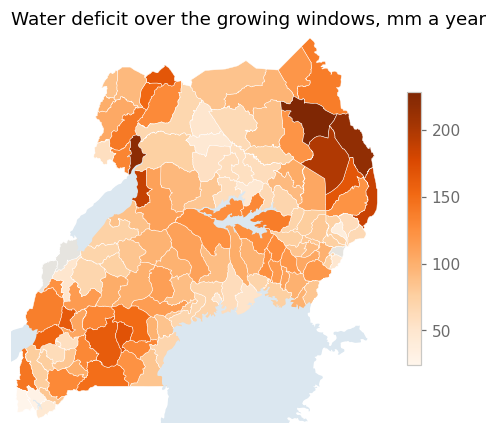

In [6]:
dm = sm_[sm_['year'].between(2000, 2024)].groupby(['pcode', 'year'])['deficit'].sum(min_count=2)
deficit = dm.groupby('pcode').mean()
need = need.join(deficit.rename('deficit'))
print(need.groupby('region')['deficit'].describe()[['min', '50%', 'max']].round(0))
fig, ax = plt.subplots(figsize=(5.5, 4.6))
sm = district_map(ax, deficit, cmap='Oranges')
ax.set_title('Water deficit over the growing windows, mm a year'); fig.colorbar(sm, ax=ax, shrink=.7)
plt.show()

## 5. Is water within reach?
* **Surface water:** share of a district's cropland within 1 km of permanent water (a lake, swamp or river wet at least 10 months a year) or of a river with mean flow of at least 1 m³/s. Small streams are not mapped at this scale, so this undercounts.
* **Groundwater:** share of the district where boreholes can typically yield at least 1 litre a second, enough for a small solar pump irrigating about 1–2 ha (BGS, 5 km). Groundwater is within 25 m of the surface almost everywhere in Uganda, so depth does not separate districts.
* **Flat land:** share of cropland on slopes of 3° (about 5%) or less, where surface irrigation is practical.
* **Sunlight** varies by up to a third between districts (cloudier in the south-west highlands, sunnier in the north-east) but is ample for solar pumps everywhere.

Median district (%):
surface_access            7.9
crop_5km_water_share      8.7
gw_yield_1ls             20.8
gw_shallow_25m          100.0
crop_flat_share          78.7
dtype: float64

By region, median (%):
          surface_access  gw_yield_1ls  crop_flat_share
region                                                 
Central              8.7          92.3             42.0
Eastern              8.6          31.6             89.4
Northern             3.8           0.0             90.8
Western             10.4          32.6             28.3

Sunlight: districts range 170–223 W/m² (mean 205); the sunniest gets 31% more than the least sunny

Existing irrigation (FAO, about 2005): 9,063 ha equipped, in 36 districts


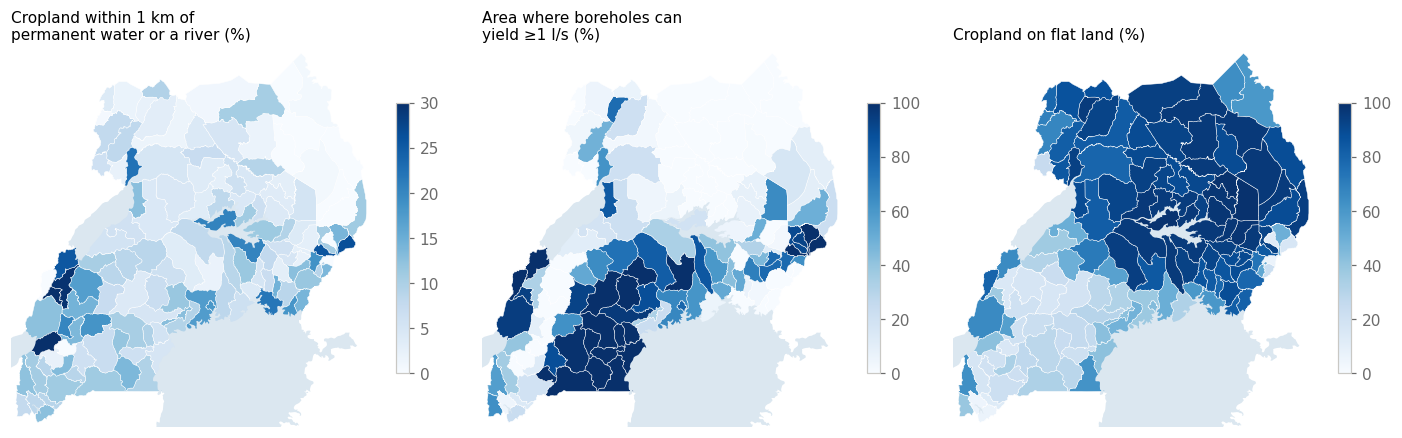

In [7]:
static = load_static()
gw = load_groundwater()
gmia = load_gmia()
feas = static.join(gw[['gw_yield_1ls', 'gw_shallow_25m']]).join(names)
feas['surface_access'] = feas[['crop_1km_water_share', 'crop_1km_river_share']].max(axis=1)
print('Median district (%):')
print((feas[['surface_access', 'crop_5km_water_share', 'gw_yield_1ls', 'gw_shallow_25m', 'crop_flat_share']].median() * 100).round(1))
print('\nBy region, median (%):')
print((feas.groupby('region')[['surface_access', 'gw_yield_1ls', 'crop_flat_share']].median() * 100).round(1))
srad = monthly.groupby('pcode')['srad'].mean()
print(f"\nSunlight: districts range {srad.min():.0f}–{srad.max():.0f} W/m² (mean {srad.mean():.0f}); "
      f"the sunniest gets {100 * (srad.max() / srad.min() - 1):.0f}% more than the least sunny")
print(f"\nExisting irrigation (FAO, about 2005): {gmia['gmia_equipped_ha'].sum():,.0f} ha equipped, in {len(gmia)} districts")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, col, t in [(axes[0], 'surface_access', 'Cropland within 1 km of\npermanent water or a river (%)'),
                   (axes[1], 'gw_yield_1ls', 'Area where boreholes can\nyield ≥1 l/s (%)'),
                   (axes[2], 'crop_flat_share', 'Cropland on flat land (%)')]:
    sm = district_map(ax, feas[col] * 100, cmap='Blues', vmin=0, vmax=100 if col != 'surface_access' else 30)
    ax.set_title(t, fontsize=10); fig.colorbar(sm, ax=ax, shrink=.6)
plt.tight_layout(); plt.show()

## 6. Need against feasibility
**Need** averages each district's percentile rank (0–100) on three measures: odds of a long dry spell, odds of a failed window, and water deficit. "Higher need" means the top half of districts.

**Water within reach** uses fixed thresholds rather than ranks, because water is either there or not: at least 10% of cropland within 1 km of permanent water or a river, **or** at least half the district where boreholes can yield 1 litre a second or more. The water score on the chart is the better of the two as a multiple of its threshold (1 or more means within reach).

Districts with under 10 km² of mapped cropland are left out (mostly urban districts and islands; the cropland map also misses most banana and coffee gardens, which are mapped as tree cover).

In [8]:
nf = need_feasibility(need[['p_long_dry', 'p_failed', 'mean_spell', 'window_rain']], deficit, static, gw).join(names).join(gmia)
print(nf['group'].value_counts())
print('\nBy region:'); print(pd.crosstab(nf['region'], nf['group']))
hn = nf[nf['group'].str.startswith('high need')]
print('\nHigh-need districts by water source:'); print(hn['water_source'].value_counts())
print('\nHigh need, water hard to reach:', ', '.join(hn[hn['water_score'] < 1].sort_values('need', ascending=False)['district']))

cols = ['district', 'region', 'need', 'water_source', 'p_long_dry', 'p_failed', 'deficit', 'surface_access',
        'gw_yield_1ls', 'crop_flat_share', 'cropland_km2', 'population']
top = nf[nf['group'] == 'high need, water within reach'].sort_values('need', ascending=False)
print('\nHigh need, water within reach (sorted by need):')
print(top[cols].round(2).to_string(index=False))
print(f"\nThese {len(top)} districts hold {top['cropland_km2'].sum():,.0f} km² of mapped cropland "
      f"({100 * top['cropland_km2'].sum() / nf['cropland_km2'].sum():.0f}% of the national total) and "
      f"{top['population'].sum() / 1e6:.1f} million people")
print(f"Existing irrigation (FAO, about 2005) in these districts: {top['gmia_equipped_ha'].sum():,.0f} ha of {nf['gmia_equipped_ha'].sum():,.0f}")

group
lower need, water within reach    40
high need, water hard to reach    34
high need, water within reach     29
lower need, harder access         22
too little cropland mapped        10
Name: count, dtype: int64

By region:
group     high need, water hard to reach  high need, water within reach  lower need, harder access  lower need, water within reach  too little cropland mapped
region                                                                                                                                                        
Central                                1                              3                          2                              17                           3
Eastern                               10                             15                          3                               8                           1
Northern                              21                              4                         10                               0     

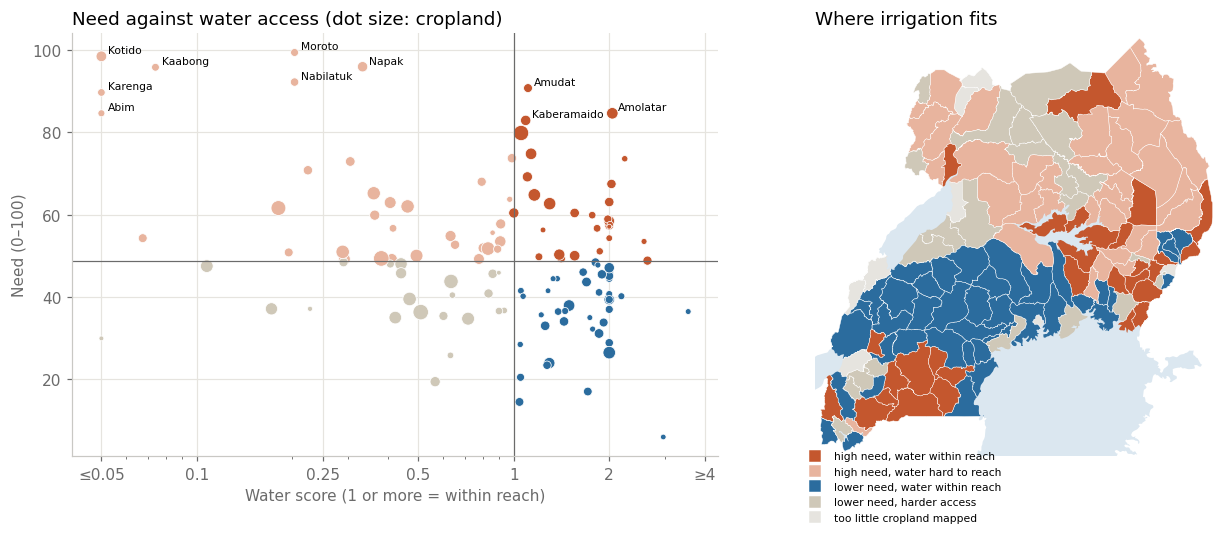

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1.15, 1]})
ax = axes[0]
x = nf.dropna(subset=['need'])
ax.axvline(1, color=GREY, lw=.8); ax.axhline(x['need'].median(), color=GREY, lw=.8)
xs = x['water_score'].clip(0.05, 4)
ax.scatter(xs, x['need'], s=np.sqrt(x['cropland_km2']) * 3, c=x['group'].map(GROUPS), edgecolor='white', lw=.5)
ax.set_xscale('log'); ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 4]); ax.set_xticklabels(['≤0.05', '0.1', '0.25', '0.5', '1', '2', '≥4'])
for _, r in x[x['need'] >= 80].iterrows():
    ax.annotate(r['district'], (min(max(r['water_score'], .05), 4), r['need']), fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.set_xlabel('Water score (1 or more = within reach)'); ax.set_ylabel('Need (0–100)')
ax.set_title('Need against water access (dot size: cropland)')
district_map(axes[1], nf['group'], colors=GROUPS)
axes[1].set_title('Where irrigation fits')
handles = [plt.Line2D([], [], marker='s', ls='', color=c, label=k) for k, c in GROUPS.items()]
axes[1].legend(handles=handles, fontsize=7, loc='lower left', bbox_to_anchor=(-.05, -.18))
plt.tight_layout(); plt.show()

**Reading the result.** The districts that need irrigation most are mostly the ones where water is hardest to reach. Almost all of Karamoja and much of the North fall in *high need, water hard to reach*: little cropland lies near permanent water, and the basement rock there gives low-yielding boreholes. In those districts the realistic options are rainwater harvesting (valley tanks, small dams), boreholes for very small plots, and drought-tolerant crops, rather than pump irrigation at scale.

The *high need, water within reach* districts are mostly in the East (Teso, the Busoga lakeshore, Elgon's foothills) and around Lake Kyoga, where surface water lies close to flat cropland. In the South-west cattle corridor (Isingiro, Kiruhura, Mbarara, Rakai, Lyantonde), groundwater is good but the land is hilly (only 20–30% of cropland is flat), so pumped drip or sprinkler systems fit better than flooding fields.

## 7. How much do the choices matter?
Each choice above is varied in turn: the rainfall-season cut-off, the dry-day threshold, the dry-spell length, the failed-window threshold and the two water thresholds. The need ranking and the priority list are recomputed each time and compared with the main ones.

In [10]:
def alt_need(cutoff=0.6, dry_mm=2.0, long_spell=LONG_DRY_SPELL, fail_share=0.75, surface_min=0.10, groundwater_min=0.5):
    reg = rainfall_regime(rain, cutoff=cutoff)[0]
    se = season_rain(rain.loc[:'2025'], reg, dry_mm=dry_mm)
    nm = need_metrics(se, long_spell=long_spell, fail_share=fail_share)
    sm2 = season_monthly(monthly, reg)
    de = sm2[sm2['year'].between(2000, 2024)].groupby(['pcode', 'year'])['deficit'].sum(min_count=2).groupby('pcode').mean()
    return need_feasibility(nm, de, static, gw, surface_min=surface_min, groundwater_min=groundwater_min)

base = nf
top_base = set(base.index[base['group'] == 'high need, water within reach'])
rows = []
for label, kw in [('season cut-off 0.5', {'cutoff': 0.5}), ('season cut-off 0.7', {'cutoff': 0.7}),
                  ('dry day < 1 mm', {'dry_mm': 1.0}), ('dry day < 5 mm', {'dry_mm': 5.0}),
                  ('dry spell 10+ days', {'long_spell': 10}), ('dry spell 21+ days', {'long_spell': 21}),
                  ('failed below 60%', {'fail_share': 0.6}), ('failed below 85%', {'fail_share': 0.85}),
                  ('water: 5% near surface water or 25% good boreholes', {'surface_min': 0.05, 'groundwater_min': 0.25}),
                  ('water: 20% near surface water or 75% good boreholes', {'surface_min': 0.20, 'groundwater_min': 0.75})]:
    a = alt_need(**kw)
    both = base[['need']].join(a[['need']], rsuffix='_alt').dropna()
    top_alt = set(a.index[a['group'] == 'high need, water within reach'])
    rows.append({'variant': label, 'need rank correlation': spearmanr(both['need'], both['need_alt'])[0],
                 'priority districts': len(top_alt), 'shared with main list': len(top_base & top_alt),
                 'main list kept (%)': 100 * len(top_base & top_alt) / len(top_base)})
sens = pd.DataFrame(rows)
print(f'Main list: {len(top_base)} districts'); print(sens.round(2).to_string(index=False))

Main list: 29 districts
                                            variant  need rank correlation  priority districts  shared with main list  main list kept (%)
                                 season cut-off 0.5                   0.91                  28                     26               89.66
                                 season cut-off 0.7                   0.94                  30                     29              100.00
                                     dry day < 1 mm                   0.96                  28                     26               89.66
                                     dry day < 5 mm                   0.86                  36                     24               82.76
                                 dry spell 10+ days                   0.94                  29                     28               96.55
                                 dry spell 21+ days                   0.82                  24                     21               72.41
          

In [11]:
nf.round(4).to_csv(PROC / 'district_need_feasibility.csv')
need.round(4).to_csv(PROC / 'district_need.csv')
crop.round(3).to_csv(PROC / 'crop_response.csv', index=False)
sens.round(3).to_csv(PROC / 'sensitivity.csv', index=False)
regime.round(3).to_csv(PROC / 'district_regime.csv')
gw.round(4).to_csv(PROC / 'district_groundwater.csv')
gmia.round(1).to_csv(PROC / 'district_existing_irrigation.csv')
print('saved')

saved
